In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
COUNTRY = "Ghana"
FILE_PATH = r"D:\Plateful_of_Data_Datathon26\FAOSTAT_Dataset\FAOSTAT_CoAHD_Ghana.csv"
 
def load_country_csv(path):
    """FAOSTAT exports with a UTF-8 BOM — utf-8-sig strips it cleanly."""
    return pd.read_csv(path, encoding="utf-8-sig")
 
df = load_country_csv(FILE_PATH)

In [10]:
def explore(df, country):
    print(f"\n{'='*50}\n{country} — shape: {df.shape}\n{'='*50}")
    print("\nUnique items:")
    print(df[["Item Code", "Item"]].drop_duplicates().to_string(index=False))
    print("\nYear coverage per item:")
    print(df.groupby(["Item Code", "Item"])["Year"].apply(lambda y: (min(y), max(y), len(y))))
    print("\nMissing values:\n", df.isna().sum().sum(), "total")
    print("\nFlags present:", df["Flag"].unique())
    print("\nUnits present:", df["Unit"].unique())
 
explore(df, COUNTRY)


Ghana — shape: (48, 15)

Unique items:
 Item Code                                                   Item
     70040                          Cost of a healthy diet (CoHD)
     70041                          Cost of a healthy diet (CoHD)
     70070                                Cost of starchy staples
     70071                                Cost of starchy staples
     70080                            Cost of animal source foods
     70081                            Cost of animal source foods
     70090                        Cost of legumes, nuts and seeds
     70091                        Cost of legumes, nuts and seeds
     70100                                     Cost of vegetables
     70101                                     Cost of vegetables
     70110                                         Cost of fruits
     70111                                         Cost of fruits
     70120                                  Cost of oils and fats
     70121                          

In [11]:
TIMESERIES_ITEMS = {
    70040: "CoHD_PPP",          # Cost of a healthy diet
    7005:  "PUA_pct",           # Prevalence of unaffordability
    7006:  "NUA_millions",      # Number unable to afford
}
 
FOODGROUP_ITEMS = {
    70040: "Total CoHD",
    70070: "Starchy staples",
    70080: "Animal source foods",
    70090: "Legumes, nuts & seeds",
    70100: "Vegetables",
    70110: "Fruits",
    70120: "Oils and fats",
}

def clean_timeseries(df, country):
    """Full-coverage annual series: cost, unaffordability %, people affected."""
    sub = df[df["Item Code"].isin(TIMESERIES_ITEMS)].copy()
    sub["metric"] = sub["Item Code"].map(TIMESERIES_ITEMS)
    wide = sub.pivot(index="Year", columns="metric", values="Value").reset_index()
    wide.insert(0, "Country", country)
    return wide[["Country", "Year", "CoHD_PPP", "PUA_pct", "NUA_millions"]]
 
def clean_foodgroups(df, country, snapshot_year=2021):
    """Cost-driver breakdown — CoAHD only publishes this for one year."""
    sub = df[(df["Item Code"].isin(FOODGROUP_ITEMS)) & (df["Year"] == snapshot_year)].copy()
    sub["group"] = sub["Item Code"].map(FOODGROUP_ITEMS)
    sub = sub[["group", "Value"]].rename(columns={"Value": "PPP_dollars_per_person_day"})
    total = sub.loc[sub["group"] == "Total CoHD", "PPP_dollars_per_person_day"].values[0]
    sub["pct_of_CoHD"] = (sub["PPP_dollars_per_person_day"] / total * 100).round(1)
    sub.insert(0, "Country", country)
    sub.insert(1, "Year", snapshot_year)
    return sub.sort_values("PPP_dollars_per_person_day", ascending=False)
 
timeseries = clean_timeseries(df, COUNTRY)
foodgroups = clean_foodgroups(df, COUNTRY)
 
print("\n--- Time series ---")
print(timeseries)
print("\n--- Food-group snapshot ---")
print(foodgroups)



--- Time series ---
metric Country  Year  CoHD_PPP  PUA_pct  NUA_millions
0        Ghana  2017      3.54     67.2          20.2
1        Ghana  2018      3.51     66.1          20.2
2        Ghana  2019      3.48     64.8          20.3
3        Ghana  2020      3.46     65.6          20.9
4        Ghana  2021      3.50     64.7          21.1
5        Ghana  2022      3.83     64.7          21.5
6        Ghana  2023      4.29     66.4          22.4
7        Ghana  2024      4.49     65.8          22.6
8        Ghana  2025      4.65     65.8          23.1

--- Food-group snapshot ---
   Country  Year                  group  PPP_dollars_per_person_day  \
4    Ghana  2021             Total CoHD                        3.50   
20   Ghana  2021    Animal source foods                        1.44   
18   Ghana  2021        Starchy staples                        0.69   
24   Ghana  2021             Vegetables                        0.46   
22   Ghana  2021  Legumes, nuts & seeds                

In [12]:
timeseries.to_csv("Ghana_CoAHD_timeseries_2017_2025.csv", index=False)
foodgroups.to_csv("Ghana_CoAHD_foodgroups_2021.csv", index=False)
print("\nSaved: Ghana_CoAHD_timeseries_2017_2025.csv, Ghana_CoAHD_foodgroups_2021.csv")
 


Saved: Ghana_CoAHD_timeseries_2017_2025.csv, Ghana_CoAHD_foodgroups_2021.csv


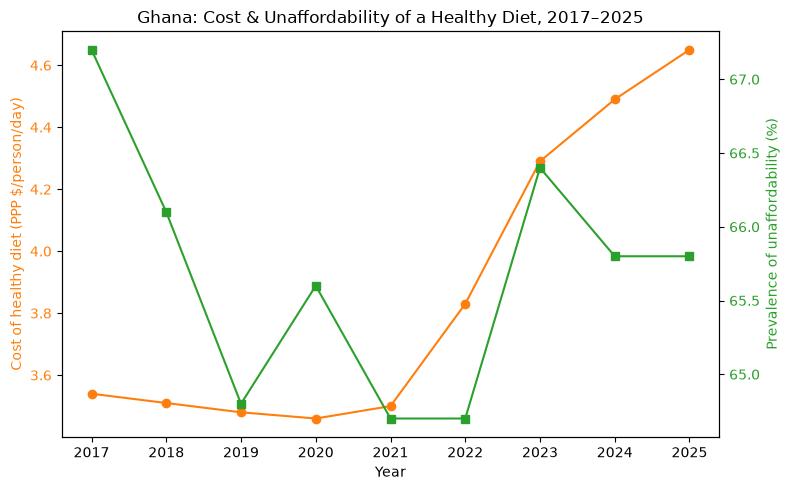

In [13]:
# 5a. Cost + unaffordability trend (dual y-axis — needed since cost is
#     ~$3-5 and PUA is ~60-70%, very different scales)
def plot_trend(d, country):
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(d["Year"], d["CoHD_PPP"], color="tab:orange", marker="o", label="Cost (PPP $/day)")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Cost of healthy diet (PPP $/person/day)", color="tab:orange")
    ax1.tick_params(axis="y", labelcolor="tab:orange")
 
    ax2 = ax1.twinx()
    ax2.plot(d["Year"], d["PUA_pct"], color="tab:green", marker="s", label="Unaffordability (%)")
    ax2.set_ylabel("Prevalence of unaffordability (%)", color="tab:green")
    ax2.tick_params(axis="y", labelcolor="tab:green")
 
    plt.title(f"{country}: Cost & Unaffordability of a Healthy Diet, 2017–2025")
    fig.tight_layout()
    plt.savefig(f"{country}_trend.png", dpi=150)
    plt.show()
    
plot_trend(timeseries, COUNTRY)

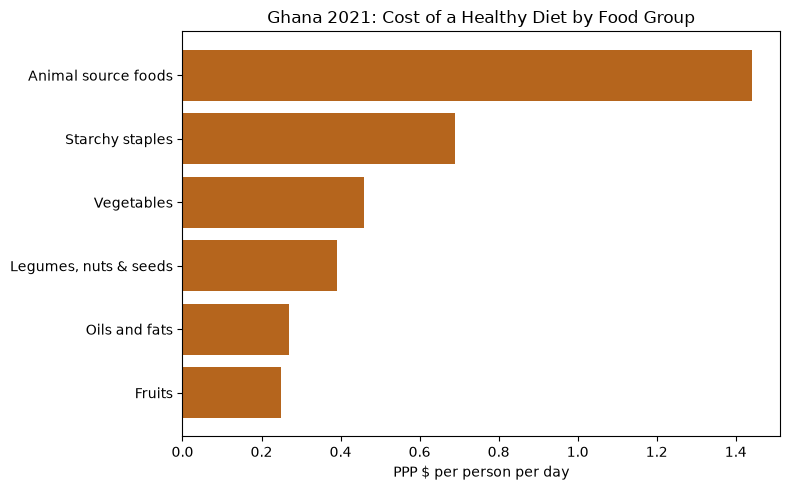

In [14]:
# 5b. Food-group cost driver breakdown
def plot_foodgroups(d, country, snapshot_year=2021):
    d = d[d["group"] != "Total CoHD"].sort_values("PPP_dollars_per_person_day", ascending=True)
    plt.figure(figsize=(8, 5))
    plt.barh(d["group"], d["PPP_dollars_per_person_day"], color="#B5651D")  # terracotta
    plt.xlabel("PPP $ per person per day")
    
    plt.title(f"{country} {snapshot_year}: Cost of a Healthy Diet by Food Group")
    plt.tight_layout()
    plt.savefig(f"{country}_foodgroups.png", dpi=150)
    plt.show()

plot_foodgroups(foodgroups, COUNTRY)